In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
import metpy
import pint
import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.units import units
import scipy as sp
from scipy.interpolate import RectBivariateSpline
import xarray as xr
from lagranto import Tra
import math
import datetime
from scipy.ndimage import rotate
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import iris
from iris.analysis.cartography import rotate_pole, rotate_winds
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter
from matplotlib.animation import FuncAnimation
import matplotlib.colors as mcolors

In [2]:
%run GEOS5functions.py
%matplotlib inline 

In [3]:
stormlist = getallstorms()

In [4]:
# Retrieve the list of all storms using the getallstorms function
stormlist = getallstorms()

In [5]:
coastal = np.concatenate([
    [1, 11, 20, 22, 24],
    np.arange(26, 36),
    [37, 42, 44],
    np.arange(45, 54),
    [56, 59, 60, 62, 64, 65, 67, 68, 71],
    np.arange(75, 91),
    [92, 98],
    np.arange(101, 108),
    np.arange(114, 125),
    np.arange(126, 133),
    [134, 137, 136, 138, 140, 141, 143, 144, 147],
    np.arange(149, 158), np.arange(159, 161),np.arange(162, 165)
])
ocean = np.concatenate([
    [0],
    np.arange(2, 11),
    np.arange(12, 20),
    [21, 23, 25, 36, 38, 39, 40, 41, 43, 57, 61, 63, 66, 69, 72, 73, 74, 91, 93, 94, 96, 97],
    np.arange(108, 114),
    [125, 133, 137, 146, 165]
])

all_of_all =  np.concatenate([coastal, ocean])

In [6]:
coasteal_selected = [1, 11, 20, 44, 62, 106, 134, 157]
ocean_selected = [5, 8, 16, 23, 61, 73, 159]
all_tc = [1, 11, 20, 44, 62, 106, 134, 157, 5, 8, 16, 23, 61, 73, 159]

In [7]:
len(all_of_all)

153

In [8]:
all_tc = all_of_all 

In [9]:
#variables listed here: https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst

# List of variable names to retrieve from the dataset
varvec = ['met' , 'aero']

# Iterate over each variable name in varvec
for vind in range(len(varvec)):
    # Construct the URL for accessing the dataset corresponding to the current variable
    url1 = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_2d_met1_Nx'
    url2 = 'https://opendap.nccs.nasa.gov/dods/OSSE/G5NR/Ganymed/7km/0.0625_deg/inst/inst30mn_2d_aer1_Nx'
    
    # Open the dataset for the current variable based on the variable name
    if varvec[vind] == 'met':
        dsmet = xr.open_dataset(url1)  # Open dataset for 'U' (zonal wind component)
    if varvec[vind] == 'aero':
        dsaero = xr.open_dataset(url2)  # Open dataset for 'U' (zonal wind component)



# Print a success message indicating that the datasets have been read successfully
print('success reading')


/gpfs/fs1/home/z/zilmana/modares/.virtualenvs/myenv/lib/python3.11/site-packages/xarray/coding/times.py:200: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
/gpfs/fs1/home/z/zilmana/modares/.virtualenvs/myenv/lib/python3.11/site-packages/xarray/coding/times.py:200: SerializationWarning: Ambiguous reference date string: 1-1-1 00:00:0.0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 00:00:0.0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)


success reading


In [10]:
dsmet

<xarray.Dataset> Size: 182TB
Dimensions:  (time: 36576, lat: 2881, lon: 5760)
Coordinates:
  * time     (time) datetime64[ns] 293kB 2005-05-15T21:30:00.000003 ... 2007-...
  * lat      (lat) float64 23kB -90.0 -89.94 -89.88 -89.81 ... 89.88 89.94 90.0
  * lon      (lon) float64 46kB -180.0 -179.9 -179.9 ... 179.8 179.9 179.9
Data variables: (12/75)
    rhoa     (time, lat, lon) float32 2TB ...
    precsno  (time, lat, lon) float32 2TB ...
    w10      (time, lat, lon) float32 2TB ...
    u50m     (time, lat, lon) float32 2TB ...
    ps       (time, lat, lon) float32 2TB ...
    ts       (time, lat, lon) float32 2TB ...
    ...       ...
    swtdn    (time, lat, lon) float32 2TB ...
    u10m     (time, lat, lon) float32 2TB ...
    snodp    (time, lat, lon) float32 2TB ...
    cldmid   (time, lat, lon) float32 2TB ...
    tox      (time, lat, lon) float32 2TB ...
    mxdiam   (time, lat, lon) float32 2TB ...
Attributes:
    title:                2d,30-Minute,Instantaneous,Single-Level,Full Resolu...
    Conventions:          COARDS\nGrADS
    dataType:             Grid
    history:              Sun Jul 28 15:49:57 UTC 2024 : imported by GrADS Da...
    extra_das_attribute:  This is an example of metadata added using a supple...

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Choose which storm to analyze

currentstorm = 72  # or just set to a specific storm ID

starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1  = stormlist[5][currentstorm]
lat2  = stormlist[6][currentstorm]
lon1  = stormlist[7][currentstorm]
lon2  = stormlist[8][currentstorm]

degbuffer = 5
buffer = degbuffer

stormname = stormlist[1][currentstorm][0:9]
print(f"Analyzing maximum wind speed for storm: {stormname}")

stormtraj = np.load('/home/z/zilmana/modares/TC/trajectory/' + str(stormname) + '.npz')
minpres = stormtraj['minpres']
timee = stormtraj['time']
minplat = stormtraj['minplat']
minplon = stormtraj['minplon']

# Use the location of minimum pressure to define the 10x10 degree domain
min_pres_idx = minpres.argmin()
center_lat = minplat[min_pres_idx]
center_lon = minplon[min_pres_idx]

latsel = slice(center_lat - buffer, center_lat + buffer)
lonsel = slice(center_lon - buffer, center_lon + buffer)

# Get reference coordinate system from first time step
first_time = timee[0]

try:
    u_ref = dsmet['u10m'].sel(time=first_time, lat=latsel, lon=lonsel)
    lat_common = u_ref.coords['lat'].values
    lon_common = u_ref.coords['lon'].values
    
    # Initialize maximum wind speed array
    max_wind_speed = np.zeros_like(u_ref.values)
    
except Exception as e:
    print(f"Error getting reference coordinates: {e}")
    exit()

time_count = 0

print(f"Processing {len(timee)} time steps...")

# Loop through all time steps in the storm's lifetime
for i, time_step in enumerate(timee):
    if i % 10 == 0:  # Print progress every 10 time steps
        print(f"Processing time step {i+1}/{len(timee)}: {time_step}")
    
    try:
        # Get wind components for this time step
        uwind = dsmet['u10m'].sel(time=time_step, lat=latsel, lon=lonsel)
        vwind = dsmet['v10m'].sel(time=time_step, lat=latsel, lon=lonsel)
        
        # Handle Southern Hemisphere storms (flip latitude if needed)
        if np.mean(uwind.lat.values) < 0:
            uwind = uwind.sel(lat=slice(None, None, -1))
            vwind = vwind.sel(lat=slice(None, None, -1))
            
        # Assign common coordinates for consistent processing
        usel = uwind.assign_coords(lat=lat_common, lon=lon_common)
        vsel = vwind.assign_coords(lat=lat_common, lon=lon_common)
        
        # Calculate horizontal wind speed for this time step
        wind_speed = np.sqrt(usel.values**2 + vsel.values**2)
        
        # Update maximum wind speed at each grid point
        max_wind_speed = np.maximum(max_wind_speed, wind_speed)
        
        time_count += 1
        
    except Exception as e:
        print(f"Skipping time step {time_step} due to error: {e}")
        continue

print(f"Successfully processed {time_count} time steps")

# Calculate maximum wind speed in the domain
max_wind_ms = np.max(max_wind_speed)
mean_wind_ms = np.mean(max_wind_speed)

print(f"Maximum wind speed in domain: {max_wind_ms:.2f} m/s")
print(f"Mean maximum wind speed: {mean_wind_ms:.2f} m/s")

# Convert m/s to mph for Saffir-Simpson Scale comparison
max_wind_mph = max_wind_ms * 2.23694  # 1 m/s = 2.23694 mph
max_wind_kts = max_wind_ms * 1.94384  # 1 m/s = 1.94384 knots

print(f"Maximum wind speed: {max_wind_mph:.1f} mph ({max_wind_kts:.1f} knots)")

# Saffir-Simpson Hurricane Wind Scale categorization
def categorize_storm(wind_speed_mph):
    """
    Categorize storm based on Saffir-Simpson Hurricane Wind Scale
    Input: wind speed in mph
    Returns: category and description
    """
    if wind_speed_mph < 39:
        return "Tropical Depression", "Wind speeds less than 39 mph"
    elif wind_speed_mph < 74:
        return "Tropical Storm", "Wind speeds 39-73 mph"
    elif wind_speed_mph < 96:
        return "Category 1 Hurricane", "Wind speeds 74-95 mph (Very dangerous winds)"
    elif wind_speed_mph < 111:
        return "Category 2 Hurricane", "Wind speeds 96-110 mph (Extremely dangerous winds)"
    elif wind_speed_mph < 130:
        return "Category 3 Hurricane", "Wind speeds 111-129 mph (Devastating damage)"
    elif wind_speed_mph < 157:
        return "Category 4 Hurricane", "Wind speeds 130-156 mph (Catastrophic damage)"
    else:
        return "Category 5 Hurricane", "Wind speeds 157+ mph (Catastrophic damage)"

# Categorize the storm
category, description = categorize_storm(max_wind_mph)

print(f"\n{'='*60}")
print(f"STORM CLASSIFICATION - SAFFIR-SIMPSON SCALE")
print(f"{'='*60}")
print(f"Storm Name: {stormname}")
print(f"Maximum Wind Speed: {max_wind_mph:.1f} mph ({max_wind_ms:.1f} m/s, {max_wind_kts:.1f} knots)")
print(f"Classification: {category}")
print(f"Description: {description}")

# Additional statistics
print(f"\n{'='*60}")
print(f"ADDITIONAL STATISTICS")
print(f"{'='*60}")
print(f"Domain analyzed: {center_lat-buffer:.1f}°N to {center_lat+buffer:.1f}°N, {center_lon-buffer:.1f}°E to {center_lon+buffer:.1f}°E")
print(f"Atmospheric level: {lev_index}")
print(f"Time steps processed: {time_count}")
print(f"Mean wind speed: {mean_wind_ms:.2f} m/s ({mean_wind_ms * 2.23694:.1f} mph)")
print(f"Standard deviation: {np.std(max_wind_speed):.2f} m/s")
print(f"95th percentile: {np.percentile(max_wind_speed, 95):.2f} m/s ({np.percentile(max_wind_speed, 95) * 2.23694:.1f} mph)")

# Percentage of domain in each category
def analyze_wind_distribution(wind_speeds_ms):
    """Analyze what percentage of the domain falls into each category"""
    wind_speeds_mph = wind_speeds_ms * 2.23694
    
    td_pct = np.sum(wind_speeds_mph < 39) / wind_speeds_mph.size * 100
    ts_pct = np.sum((wind_speeds_mph >= 39) & (wind_speeds_mph < 74)) / wind_speeds_mph.size * 100
    cat1_pct = np.sum((wind_speeds_mph >= 74) & (wind_speeds_mph < 96)) / wind_speeds_mph.size * 100
    cat2_pct = np.sum((wind_speeds_mph >= 96) & (wind_speeds_mph < 111)) / wind_speeds_mph.size * 100
    cat3_pct = np.sum((wind_speeds_mph >= 111) & (wind_speeds_mph < 130)) / wind_speeds_mph.size * 100
    cat4_pct = np.sum((wind_speeds_mph >= 130) & (wind_speeds_mph < 157)) / wind_speeds_mph.size * 100
    cat5_pct = np.sum(wind_speeds_mph >= 157) / wind_speeds_mph.size * 100
    
    return td_pct, ts_pct, cat1_pct, cat2_pct, cat3_pct, cat4_pct, cat5_pct

td_pct, ts_pct, cat1_pct, cat2_pct, cat3_pct, cat4_pct, cat5_pct = analyze_wind_distribution(max_wind_speed)

print(f"\n{'='*60}")
print(f"WIND SPEED DISTRIBUTION ACROSS DOMAIN")
print(f"{'='*60}")
print(f"Tropical Depression (< 39 mph): {td_pct:.1f}% of domain")
print(f"Tropical Storm (39-73 mph): {ts_pct:.1f}% of domain")
print(f"Category 1 Hurricane (74-95 mph): {cat1_pct:.1f}% of domain")
print(f"Category 2 Hurricane (96-110 mph): {cat2_pct:.1f}% of domain")
print(f"Category 3 Hurricane (111-129 mph): {cat3_pct:.1f}% of domain")
print(f"Category 4 Hurricane (130-156 mph): {cat4_pct:.1f}% of domain")
print(f"Category 5 Hurricane (157+ mph): {cat5_pct:.1f}% of domain")

print(f"\n{'='*60}")
print(f"ANALYSIS COMPLETE")
print(f"{'='*60}")

Analyzing maximum wind speed for storm: npc05tc19
Processing 284 time steps...
Processing time step 1/284: 2005-10-05T12:30:00.000003000
Processing time step 11/284: 2005-10-05T17:29:59.999997000
Processing time step 21/284: 2005-10-05T22:30:00.000000000
Processing time step 31/284: 2005-10-06T03:30:00.000003000
Processing time step 41/284: 2005-10-06T08:29:59.999997000
Processing time step 51/284: 2005-10-06T13:30:00.000000000
Processing time step 61/284: 2005-10-06T18:30:00.000003000
Processing time step 71/284: 2005-10-06T23:29:59.999997000
Processing time step 81/284: 2005-10-07T04:30:00.000000000
Processing time step 91/284: 2005-10-07T09:30:00.000003000
Processing time step 101/284: 2005-10-07T14:29:59.999997000
Processing time step 111/284: 2005-10-07T19:30:00.000000000
Processing time step 121/284: 2005-10-08T00:30:00.000003000
Processing time step 131/284: 2005-10-08T05:29:59.999997000
Processing time step 141/284: 2005-10-08T10:30:00.000000000
Processing time step 151/284: 20

NameError: name 'lev_index' is not defined

# one time step

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ——— User inputs ———
currentstorm  = 74    # storm ID
snapshot_idx  = 20     # zero‑based index of the time step you want to analyze
degbuffer     = 10     # domain half‑width in degrees

# ——— Extract storm metadata ———
starttime = stormlist[3][currentstorm]
endtime   = stormlist[4][currentstorm]
lat1      = stormlist[5][currentstorm]
lat2      = stormlist[6][currentstorm]
lon1      = stormlist[7][currentstorm]
lon2      = stormlist[8][currentstorm]
stormname = stormlist[1][currentstorm][0:9]
print(f"Analyzing storm '{stormname}' at a single snapshot")

# ——— Load trajectory & find center at min pressure ———
stormtraj   = np.load(f'/home/z/zilmana/modares/TC/trajectory/{stormname}.npz')
minpres     = stormtraj['minpres']
timee       = stormtraj['time']
minplat     = stormtraj['minplat']
minplon     = stormtraj['minplon']
min_idx     = minpres.argmin()
center_lat  = minplat[min_idx]
center_lon  = minplon[min_idx]

buffer      = degbuffer
latsel      = slice(center_lat - buffer, center_lat + buffer)
lonsel      = slice(center_lon - buffer, center_lon + buffer)

# ——— Grab reference coords from the first snapshot ———
first_time   = timee[0]
u_ref        = dsmet['u10m'].sel(time=first_time, lat=latsel, lon=lonsel)
lat_common   = u_ref.coords['lat'].values
lon_common   = u_ref.coords['lon'].values

# ——— Pick the snapshot ———
snapshot_time = timee[snapshot_idx]
print(f"Snapshot time: {snapshot_time}")

# ——— Load u/v at snapshot and compute wind speed array ———
uwind = dsmet['u10m'].sel(time=snapshot_time, lat=latsel, lon=lonsel)
vwind = dsmet['v10m'].sel(time=snapshot_time, lat=latsel, lon=lonsel)

# If in Southern Hemisphere, flip lat ordering
if np.mean(uwind.lat.values) < 0:
    uwind = uwind.sel(lat=slice(None, None, -1))
    vwind = vwind.sel(lat=slice(None, None, -1))

# Re‑assign to common grid
uwind = uwind.assign_coords(lat=lat_common, lon=lon_common)
vwind = vwind.assign_coords(lat=lat_common, lon=lon_common)

# Compute instantaneous wind‐speed field (m/s)
wind_speed = np.sqrt(uwind.values**2 + vwind.values**2)

# ——— Basic stats ———
max_wind_ms  = wind_speed.max()
mean_wind_ms = wind_speed.mean()
std_wind_ms  = wind_speed.std()
p95_wind_ms  = np.percentile(wind_speed, 95)

# Convert to mph & knots
max_wind_mph = max_wind_ms * 2.23694
max_wind_kts = max_wind_ms * 1.94384

print(f"Maximum wind: {max_wind_ms:.1f} m/s ({max_wind_mph:.1f} mph, {max_wind_kts:.1f} knots)")
print(f"Mean wind:    {mean_wind_ms:.1f} m/s")
print(f"Std dev:      {std_wind_ms:.1f} m/s")
print(f"95th pctile:  {p95_wind_ms:.1f} m/s")

# ——— Saffir-Simpson categorization ———
def categorize_storm(wind_speed_mph):
    if wind_speed_mph < 39:
        return "Tropical Depression", "Wind speeds less than 39 mph"
    elif wind_speed_mph < 74:
        return "Tropical Storm",     "Wind speeds 39–73 mph"
    elif wind_speed_mph < 96:
        return "Category 1 Hurricane", "74–95 mph"
    elif wind_speed_mph < 111:
        return "Category 2 Hurricane", "96–110 mph"
    elif wind_speed_mph < 130:
        return "Category 3 Hurricane", "111–129 mph"
    elif wind_speed_mph < 157:
        return "Category 4 Hurricane", "130–156 mph"
    else:
        return "Category 5 Hurricane", "157+ mph"

category, description = categorize_storm(max_wind_mph)

print("\n" + "="*50)
print("STORM CLASSIFICATION")
print("="*50)
print(f"Storm:       {stormname}")
print(f"Snapshot:    {snapshot_time}")
print(f"Max wind:    {max_wind_mph:.1f} mph — {category}")
print(f"Description: {description}")
print("="*50)

# ——— Optional: distribution across grid at this time ———
def analyze_wind_distribution(ws_ms):
    ws_mph = ws_ms * 2.23694
    bins = [
        np.sum(ws_mph < 39),
        np.sum((ws_mph >= 39) & (ws_mph < 74)),
        np.sum((ws_mph >= 74) & (ws_mph < 96)),
        np.sum((ws_mph >= 96) & (ws_mph < 111)),
        np.sum((ws_mph >= 111) & (ws_mph < 130)),
        np.sum((ws_mph >= 130) & (ws_mph < 157)),
        np.sum(ws_mph >= 157),
    ]
    return [b / ws_mph.size * 100 for b in bins]

td, ts, c1, c2, c3, c4, c5 = analyze_wind_distribution(wind_speed)
print("Grid‑point distribution at snapshot:")
print(f" TD: {td:.1f}%, TS: {ts:.1f}%, Cat1: {c1:.1f}%, Cat2: {c2:.1f}%, Cat3: {c3:.1f}%, Cat4: {c4:.1f}%, Cat5: {c5:.1f}%")


Analyzing storm 'npc05tc21' at a single snapshot
Snapshot time: 2005-10-09T20:29:59.999997000
Maximum wind: 37.7 m/s (84.3 mph, 73.2 knots)
Mean wind:    8.1 m/s
Std dev:      2.7 m/s
95th pctile:  11.6 m/s

STORM CLASSIFICATION
Storm:       npc05tc21
Snapshot:    2005-10-09T20:29:59.999997000
Max wind:    84.3 mph — Category 1 Hurricane
Description: 74–95 mph
Grid‑point distribution at snapshot:
 TD: 99.8%, TS: 0.2%, Cat1: 0.0%, Cat2: 0.0%, Cat3: 0.0%, Cat4: 0.0%, Cat5: 0.0%


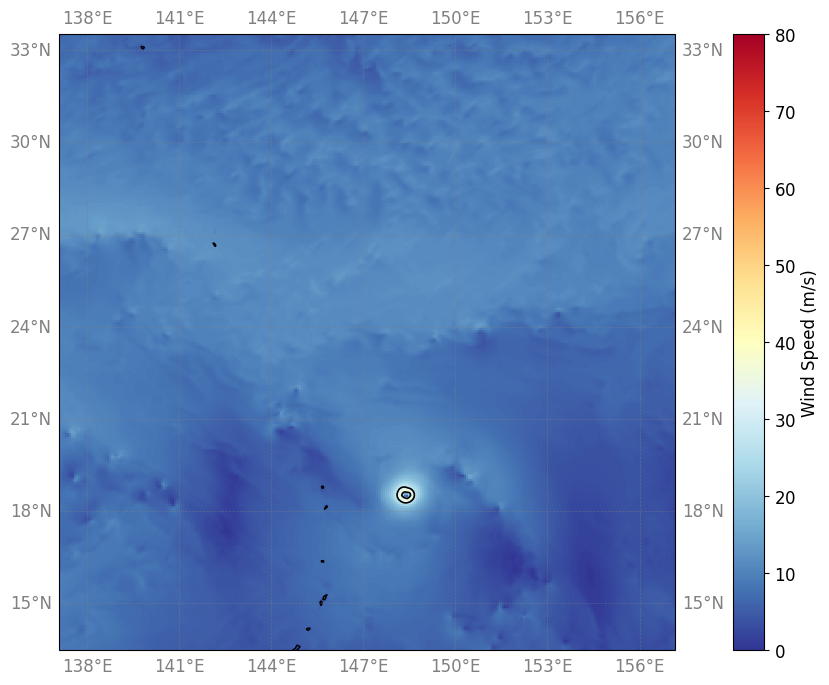

In [54]:
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl

arg = 121

mpl.rcParams.update({'font.size': 12})  # Change 12 to your preferred base size


fig, ax = plt.subplots(figsize=(15, 8), subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, edgecolor='black')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

uwind = dsmet['u10m'].sel(time=snapshot_time, lat=latsel, lon=lonsel)
vwind = dsmet['v10m'].sel(time=snapshot_time, lat=latsel, lon=lonsel)

  

# Calculate wind speed
wind_speed = np.sqrt(uwind**2 + vwind**2)

# Streamlines
u_selected_np = uwind.values
v_selected_np = vwind.values
wind_speed_np = wind_speed.values


wind_speed_np = wind_speed_np 

#wind_speed_np = wind_speed_np * (np.log(10/0.0002))/(np.log(h_low.mean()/0.0002))


# Addinf so2

so2_min =  0 #wind_speed_np.where(wind_speed_np > 0).min().item()
so2_max =  80#wind_speed_np.where(wind_speed_np > 0).max().item()

so2_plot = ax.pcolormesh(
    uwind.lon, uwind.lat, wind_speed_np, 
    cmap='RdYlBu_r',  # A contrasting colormap from 'viridis'
    norm=mcolors.Normalize(vmin=so2_min, vmax=so2_max)
)

cbar2 = fig.colorbar(so2_plot, ax=ax, orientation='vertical')
cbar2.set_label('Wind Speed (m/s)')

# Set scientific notation
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-3, 3))  # Forces scientific notation for small/large values
cbar2.ax.yaxis.set_major_formatter(formatter)




# Optionally smooth wind speed (contact velocity) if needed
smoothed_wind = gaussian_filter(wind_speed_np, sigma=0)

# Define contour levels for contact velocity
contour_levels = [30,  40, 50, 60, 65, 70, 75] # np.linspace(np.nanmin(smoothed_wind), np.nanmax(smoothed_wind), 10)

# Add contour lines
contour = ax.contour(
    uwind.lon, uwind.lat, smoothed_wind,
    levels=contour_levels,
    colors='black', linewidths=1.2, transform=ccrs.PlateCarree()
)

# Add labels to contours
ax.clabel(contour, inline=True, fontsize=10, fmt="%.1f")





crs0 = ccrs.PlateCarree()
gl = ax.gridlines(crs=crs0, draw_labels=True,
          linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.xlabel_style = {'size':12,'color':'gray'}
gl.ylabel_style = {'size':12,'color':'gray'}

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')



plt.show()    


# Categorize all

In [ ]:
import numpy as np
import pandas as pd

# Saffir-Simpson Hurricane Wind Scale categorization function
def categorize_storm(wind_speed_mph):
    """
    Categorize storm based on Saffir-Simpson Hurricane Wind Scale
    Input: wind speed in mph
    Returns: category and description
    """
    if wind_speed_mph < 39:
        return "Tropical Depression", "Wind speeds less than 39 mph"
    elif wind_speed_mph < 74:
        return "Tropical Storm", "Wind speeds 39-73 mph"
    elif wind_speed_mph < 96:
        return "Category 1 Hurricane", "Wind speeds 74-95 mph (Very dangerous winds)"
    elif wind_speed_mph < 111:
        return "Category 2 Hurricane", "Wind speeds 96-110 mph (Extremely dangerous winds)"
    elif wind_speed_mph < 130:
        return "Category 3 Hurricane", "Wind speeds 111-129 mph (Devastating damage)"
    elif wind_speed_mph < 157:
        return "Category 4 Hurricane", "Wind speeds 130-156 mph (Catastrophic damage)"
    else:
        return "Category 5 Hurricane", "Wind speeds 157+ mph (Catastrophic damage)"

# Wind speed distribution analysis function
def analyze_wind_distribution(wind_speeds_ms):
    """Analyze what percentage of the domain falls into each category"""
    wind_speeds_mph = wind_speeds_ms * 2.23694
    
    td_pct = np.sum(wind_speeds_mph < 39) / wind_speeds_mph.size * 100
    ts_pct = np.sum((wind_speeds_mph >= 39) & (wind_speeds_mph < 74)) / wind_speeds_mph.size * 100
    cat1_pct = np.sum((wind_speeds_mph >= 74) & (wind_speeds_mph < 96)) / wind_speeds_mph.size * 100
    cat2_pct = np.sum((wind_speeds_mph >= 96) & (wind_speeds_mph < 111)) / wind_speeds_mph.size * 100
    cat3_pct = np.sum((wind_speeds_mph >= 111) & (wind_speeds_mph < 130)) / wind_speeds_mph.size * 100
    cat4_pct = np.sum((wind_speeds_mph >= 130) & (wind_speeds_mph < 157)) / wind_speeds_mph.size * 100
    cat5_pct = np.sum(wind_speeds_mph >= 157) / wind_speeds_mph.size * 100
    
    return td_pct, ts_pct, cat1_pct, cat2_pct, cat3_pct, cat4_pct, cat5_pct

# Initialize lists to store results for all storms
storm_results = []

degbuffer = 5
buffer = degbuffer
lev_index = 72
print(f"Analyzing {len(all_tc)} storms...")
print(f"Domain size: {degbuffer}°×{degbuffer}°")
print(f"Atmospheric level: {lev_index}")
print("="*80)

# Loop through all storms
for storm_idx, currentstorm in enumerate(all_tc):
    print(f"\nProcessing storm {storm_idx + 1}/{len(all_tc)}")
    
    try:
        starttime = stormlist[3][currentstorm]
        endtime   = stormlist[4][currentstorm]
        lat1  = stormlist[5][currentstorm]
        lat2  = stormlist[6][currentstorm]
        lon1  = stormlist[7][currentstorm]
        lon2  = stormlist[8][currentstorm]

        stormname = stormlist[1][currentstorm][0:9]
        print(f"Storm: {stormname}")

        # Load storm trajectory data
        stormtraj = np.load('/home/z/zilmana/modares/TC/trajectory/' + str(stormname) + '.npz')
        minpres = stormtraj['minpres']
        timee = stormtraj['time']
        minplat = stormtraj['minplat']
        minplon = stormtraj['minplon']

        # Use the location of minimum pressure to define the domain
        min_pres_idx = minpres.argmin()
        center_lat = minplat[min_pres_idx]
        center_lon = minplon[min_pres_idx]

        latsel = slice(center_lat - buffer, center_lat + buffer)
        lonsel = slice(center_lon - buffer, center_lon + buffer)

        # Get reference coordinate system from first time step
        first_time = timee[0]
        u_ref = dsu['u'].sel(time=first_time, lat=latsel, lon=lonsel, lev=lev_index)
        lat_common = u_ref.coords['lat'].values
        lon_common = u_ref.coords['lon'].values

        # Initialize maximum wind speed array
        max_wind_speed = np.zeros_like(u_ref.values)
        time_count = 0

        # Loop through all time steps in the storm's lifetime
        for time_step in timee:
            try:
                # Get wind components for this time step
                uwind = dsmet['u10m'].sel(time=time_step, lat=latsel, lon=lonsel)
                vwind = dsmet['v10m'].sel(time=time_step, lat=latsel, lon=lonsel)

                # Handle Southern Hemisphere storms (flip latitude if needed)
                if np.mean(uwind.lat.values) < 0:
                    uwind = uwind.sel(lat=slice(None, None, -1))
                    vwind = vwind.sel(lat=slice(None, None, -1))

                # Assign common coordinates for consistent processing
                usel = uwind.assign_coords(lat=lat_common, lon=lon_common)
                vsel = vwind.assign_coords(lat=lat_common, lon=lon_common)

                # Calculate horizontal wind speed for this time step
                wind_speed = np.sqrt(usel.values**2 + vsel.values**2)

                # Update maximum wind speed at each grid point
                max_wind_speed = np.maximum(max_wind_speed, wind_speed)

                time_count += 1

            except Exception as e:
                continue

        # Calculate statistics for this storm
        max_wind_ms = np.max(max_wind_speed)
        mean_wind_ms = np.mean(max_wind_speed)
        std_wind_ms = np.std(max_wind_speed)
        
        # Convert to mph and knots
        max_wind_mph = max_wind_ms * 2.23694
        max_wind_kts = max_wind_ms * 1.94384
        mean_wind_mph = mean_wind_ms * 2.23694

        # Categorize the storm
        category, description = categorize_storm(max_wind_mph)

        # Get wind distribution
        td_pct, ts_pct, cat1_pct, cat2_pct, cat3_pct, cat4_pct, cat5_pct = analyze_wind_distribution(max_wind_speed)

        # Store results
        storm_result = {
            'storm_name': stormname,
            'storm_index': currentstorm,
            'max_wind_ms': max_wind_ms,
            'max_wind_mph': max_wind_mph,
            'max_wind_kts': max_wind_kts,
            'mean_wind_ms': mean_wind_ms,
            'mean_wind_mph': mean_wind_mph,
            'std_wind_ms': std_wind_ms,
            'category': category,
            'description': description,
            'center_lat': center_lat,
            'center_lon': center_lon,
            'time_steps': time_count,
            'td_pct': td_pct,
            'ts_pct': ts_pct,
            'cat1_pct': cat1_pct,
            'cat2_pct': cat2_pct,
            'cat3_pct': cat3_pct,
            'cat4_pct': cat4_pct,
            'cat5_pct': cat5_pct
        }
        
        storm_results.append(storm_result)

        print(f"  Max wind: {max_wind_mph:.1f} mph ({max_wind_ms:.1f} m/s)")
        print(f"  Classification: {category}")
        print(f"  Time steps: {time_count}")

    except Exception as e:
        print(f"  ERROR processing storm {stormname}: {e}")
        continue

print(f"\n{'='*80}")
print(f"ANALYSIS COMPLETE - PROCESSED {len(storm_results)} STORMS")
print(f"{'='*80}")

# Create DataFrame for easier analysis
df = pd.DataFrame(storm_results)

# Summary statistics
print(f"\nSTORM CATEGORY DISTRIBUTION:")
print(f"{'='*50}")
category_counts = df['category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{category}: {count} storms ({percentage:.1f}%)")

print(f"\nWIND SPEED STATISTICS:")
print(f"{'='*50}")
print(f"Maximum wind speed across all storms: {df['max_wind_mph'].max():.1f} mph ({df['max_wind_ms'].max():.1f} m/s)")
print(f"Minimum wind speed across all storms: {df['max_wind_mph'].min():.1f} mph ({df['max_wind_ms'].min():.1f} m/s)")
print(f"Mean wind speed across all storms: {df['max_wind_mph'].mean():.1f} mph ({df['max_wind_ms'].mean():.1f} m/s)")
print(f"Median wind speed across all storms: {df['max_wind_mph'].median():.1f} mph ({df['max_wind_ms'].median():.1f} m/s)")
print(f"Standard deviation: {df['max_wind_mph'].std():.1f} mph ({df['max_wind_ms'].std():.1f} m/s)")

# Top 10 strongest storms
print(f"\nTOP 10 STRONGEST STORMS:")
print(f"{'='*50}")
top_storms = df.nlargest(10, 'max_wind_mph')
for idx, storm in top_storms.iterrows():
    print(f"{storm['storm_name']}: {storm['max_wind_mph']:.1f} mph - {storm['category']}")

# Detailed results for each storm
print(f"\nDETAILED RESULTS FOR ALL STORMS:")
print(f"{'='*80}")
print(f"{'Storm':<12} {'Max Wind (mph)':<15} {'Max Wind (m/s)':<15} {'Category':<25} {'Time Steps':<12}")
print(f"{'-'*80}")

for _, storm in df.iterrows():
    print(f"{storm['storm_name']:<12} {storm['max_wind_mph']:<15.1f} {storm['max_wind_ms']:<15.1f} {storm['category']:<25} {storm['time_steps']:<12}")

# Save results to CSV
df.to_csv('seri_storm_classification_results_alltimes.csv', index=False)
print(f"\nResults saved to 'storm_classification_results.csv'")

# Category-specific statistics
print(f"\nCATEGORY-SPECIFIC WIND SPEED RANGES:")
print(f"{'='*50}")
for category in df['category'].unique():
    cat_data = df[df['category'] == category]
    print(f"{category}:")
    print(f"  Count: {len(cat_data)} storms")
    print(f"  Wind speed range: {cat_data['max_wind_mph'].min():.1f} - {cat_data['max_wind_mph'].max():.1f} mph")
    print(f"  Average wind speed: {cat_data['max_wind_mph'].mean():.1f} mph")

Analyzing 153 storms...
Domain size: 5°×5°
Atmospheric level: 72

Processing storm 1/153
Storm: atl05tc02
  Max wind: 146.7 mph (65.6 m/s)
  Classification: Category 4 Hurricane
  Time steps: 199

Processing storm 2/153
Storm: atl05tc12
  Max wind: 151.0 mph (67.5 m/s)
  Classification: Category 4 Hurricane
  Time steps: 250

Processing storm 3/153
Storm: atl06tc04
  Max wind: 131.6 mph (58.8 m/s)
  Classification: Category 4 Hurricane
  Time steps: 220

Processing storm 4/153
Storm: atl06tc06
  Max wind: 128.8 mph (57.6 m/s)
  Classification: Category 3 Hurricane
  Time steps: 172

Processing storm 5/153
Storm: atl06tc08
  Max wind: 119.8 mph (53.6 m/s)
  Classification: Category 3 Hurricane
  Time steps: 121

Processing storm 6/153
Storm: atl06tc10
  Max wind: 113.9 mph (50.9 m/s)
  Classification: Category 3 Hurricane
  Time steps: 264

Processing storm 7/153
Storm: epc05tc01
  Max wind: 83.9 mph (37.5 m/s)
  Classification: Category 1 Hurricane
  Time steps: 262

Processing storm 8

In [23]:
import numpy as np
import pandas as pd

# Saffir-Simpson Hurricane Wind Scale categorization function
def categorize_storm(wind_speed_mph):
    """
    Categorize storm based on Saffir-Simpson Hurricane Wind Scale
    Input: wind speed in mph
    Returns: category and description
    """
    if wind_speed_mph < 39:
        return "Tropical Depression", "Wind speeds less than 39 mph"
    elif wind_speed_mph < 74:
        return "Tropical Storm", "Wind speeds 39-73 mph"
    elif wind_speed_mph < 96:
        return "1", "Wind speeds 74-95 mph (Very dangerous winds)"
    elif wind_speed_mph < 111:
        return "2", "Wind speeds 96-110 mph (Extremely dangerous winds)"
    elif wind_speed_mph < 130:
        return "3", "Wind speeds 111-129 mph (Devastating damage)"
    elif wind_speed_mph < 157:
        return "4", "Wind speeds 130-156 mph (Catastrophic damage)"
    else:
        return "5", "Wind speeds 157+ mph (Catastrophic damage)"

# Wind speed distribution analysis function

# Initialize lists to store results for all storms
storm_results = []

degbuffer = 5
buffer = degbuffer

print(f"Analyzing {len(all_tc)} storms...")
print(f"Domain size: {degbuffer}°×{degbuffer}°")
print(f"Atmospheric level: {lev_index}")
print("="*80)

# Loop through all storms
for storm_idx, currentstorm in enumerate(all_tc):
    print(f"\nProcessing storm {storm_idx + 1}/{len(all_tc)}")
    
    try:
        starttime = stormlist[3][currentstorm]
        endtime   = stormlist[4][currentstorm]
        lat1  = stormlist[5][currentstorm]
        lat2  = stormlist[6][currentstorm]
        lon1  = stormlist[7][currentstorm]
        lon2  = stormlist[8][currentstorm]

        stormname = stormlist[1][currentstorm][0:9]
        print(f"Storm: {stormname}")

        # Load storm trajectory data
        stormtraj = np.load('/home/z/zilmana/modares/TC/trajectory/' + str(stormname) + '.npz')
        minpres = stormtraj['minpres']
        timee = stormtraj['time']
        minplat = stormtraj['minplat']
        minplon = stormtraj['minplon']

        # Use the location of minimum pressure to define the domain
        min_pres_idx = minpres.argmin()
        center_lat = minplat[min_pres_idx]
        center_lon = minplon[min_pres_idx]

        latsel = slice(center_lat - buffer, center_lat + buffer)
        lonsel = slice(center_lon - buffer, center_lon + buffer)

        # Find the time of minimum pressure
        min_time = timee[minpres.argmin()]
        
        # Get wind components at the time of minimum pressure
        uwind = dsmet['u10m'].sel(time=min_time, lat=latsel, lon=lonsel)
        vwind = dsmet['v10m'].sel(time=min_time, lat=latsel, lon=lonsel)

        # Handle Southern Hemisphere storms (flip latitude if needed)
        if np.mean(uwind.lat.values) < 0:
            uwind = uwind.sel(lat=slice(None, None, -1))
            vwind = vwind.sel(lat=slice(None, None, -1))

        # Get coordinates
        lat_common = uwind.coords['lat'].values
        lon_common = uwind.coords['lon'].values

        # Calculate horizontal wind speed at minimum pressure time
        wind_speed = np.sqrt(uwind.values**2 + vwind.values**2)
        max_wind_speed = wind_speed
        time_count = 1  # Only one time step (minimum pressure time)

        # Calculate statistics for this storm
        max_wind_ms = np.max(max_wind_speed)
        mean_wind_ms = np.mean(max_wind_speed)
        std_wind_ms = np.std(max_wind_speed)
        
        # Convert to mph and knots
        max_wind_mph = max_wind_ms * 2.23694
        max_wind_kts = max_wind_ms * 1.94384
        mean_wind_mph = mean_wind_ms * 2.23694

        # Categorize the storm
        category, description = categorize_storm(max_wind_mph)

        # Get wind distribution
        

        # Store results
        storm_result = {
            'storm_name': stormname,
            'storm_index': currentstorm,
            'max_wind_ms': max_wind_ms,
            'max_wind_mph': max_wind_mph,
            'max_wind_kts': max_wind_kts,
            'mean_wind_ms': mean_wind_ms,
            'mean_wind_mph': mean_wind_mph,
            'std_wind_ms': std_wind_ms,
            'category': category,
            'description': description,
            'center_lat': center_lat,
            'center_lon': center_lon,
            'time_steps': time_count
        }
        
        storm_results.append(storm_result)

        print(f"  Max wind: {max_wind_mph:.1f} mph ({max_wind_ms:.1f} m/s)")
        print(f"  Classification: {category}")
        print(f"  Time steps: {time_count}")

    except Exception as e:
        print(f"  ERROR processing storm {stormname}: {e}")
        continue

print(f"\n{'='*80}")
print(f"ANALYSIS COMPLETE - PROCESSED {len(storm_results)} STORMS")
print(f"{'='*80}")

# Create DataFrame for easier analysis
df = pd.DataFrame(storm_results)

# Summary statistics
print(f"\nSTORM CATEGORY DISTRIBUTION:")
print(f"{'='*50}")
category_counts = df['category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{category}: {count} storms ({percentage:.1f}%)")

print(f"\nWIND SPEED STATISTICS:")
print(f"{'='*50}")
print(f"Maximum wind speed across all storms: {df['max_wind_mph'].max():.1f} mph ({df['max_wind_ms'].max():.1f} m/s)")
print(f"Minimum wind speed across all storms: {df['max_wind_mph'].min():.1f} mph ({df['max_wind_ms'].min():.1f} m/s)")
print(f"Mean wind speed across all storms: {df['max_wind_mph'].mean():.1f} mph ({df['max_wind_ms'].mean():.1f} m/s)")
print(f"Median wind speed across all storms: {df['max_wind_mph'].median():.1f} mph ({df['max_wind_ms'].median():.1f} m/s)")
print(f"Standard deviation: {df['max_wind_mph'].std():.1f} mph ({df['max_wind_ms'].std():.1f} m/s)")

# Top 10 strongest storms
print(f"\nTOP 10 STRONGEST STORMS:")
print(f"{'='*50}")
top_storms = df.nlargest(10, 'max_wind_mph')
for idx, storm in top_storms.iterrows():
    print(f"{storm['storm_name']}: {storm['max_wind_mph']:.1f} mph - {storm['category']}")

# Detailed results for each storm
print(f"\nDETAILED RESULTS FOR ALL STORMS:")
print(f"{'='*80}")
print(f"{'Storm':<12} {'Max Wind (mph)':<15} {'Max Wind (m/s)':<15} {'Category':<25} {'Time Steps':<12}")
print(f"{'-'*80}")

for _, storm in df.iterrows():
    print(f"{storm['storm_name']:<12} {storm['max_wind_mph']:<15.1f} {storm['max_wind_ms']:<15.1f} {storm['category']:<25} {storm['time_steps']:<12}")

# Save results to CSV
df.to_csv('storm_classification_results_at_minpress.csv', index=False)
print(f"\nResults saved to 'storm_classification_results.csv'")

# Category-specific statistics
print(f"\nCATEGORY-SPECIFIC WIND SPEED RANGES:")
print(f"{'='*50}")
for category in df['category'].unique():
    cat_data = df[df['category'] == category]
    print(f"{category}:")
    print(f"  Count: {len(cat_data)} storms")
    print(f"  Wind speed range: {cat_data['max_wind_mph'].min():.1f} - {cat_data['max_wind_mph'].max():.1f} mph")
    print(f"  Average wind speed: {cat_data['max_wind_mph'].mean():.1f} mph")

Analyzing 153 storms...
Domain size: 5°×5°
Atmospheric level: 40

Processing storm 1/153
Storm: atl05tc02
  Max wind: 146.7 mph (65.6 m/s)
  Classification: 4
  Time steps: 1

Processing storm 2/153
Storm: atl05tc12
  Max wind: 129.7 mph (58.0 m/s)
  Classification: 3
  Time steps: 1

Processing storm 3/153
Storm: atl06tc04
  Max wind: 131.6 mph (58.8 m/s)
  Classification: 4
  Time steps: 1

Processing storm 4/153
Storm: atl06tc06
  Max wind: 124.5 mph (55.7 m/s)
  Classification: 3
  Time steps: 1

Processing storm 5/153
Storm: atl06tc08
  Max wind: 118.5 mph (53.0 m/s)
  Classification: 3
  Time steps: 1

Processing storm 6/153
Storm: atl06tc10
  Max wind: 113.1 mph (50.6 m/s)
  Classification: 3
  Time steps: 1

Processing storm 7/153
Storm: epc05tc01
  Max wind: 78.9 mph (35.3 m/s)
  Classification: 1
  Time steps: 1

Processing storm 8/153
Storm: epc05tc02
  Max wind: 112.9 mph (50.5 m/s)
  Classification: 3
  Time steps: 1

Processing storm 9/153
Storm: epc05tc03
  Max wind: 89.

In [25]:
import numpy as np
import pandas as pd

# Saffir-Simpson Hurricane Wind Scale categorization function
def categorize_storm(wind_speed_mph):
    """
    Categorize storm based on Saffir-Simpson Hurricane Wind Scale
    Input: wind speed in mph
    Returns: category and description
    """
    if wind_speed_mph < 39:
        return "Tropical Depression", "Wind speeds less than 39 mph"
    elif wind_speed_mph < 74:
        return "Tropical Storm", "Wind speeds 39-73 mph"
    elif wind_speed_mph < 96:
        return "Category 1 Hurricane", "Wind speeds 74-95 mph (Very dangerous winds)"
    elif wind_speed_mph < 111:
        return "Category 2 Hurricane", "Wind speeds 96-110 mph (Extremely dangerous winds)"
    elif wind_speed_mph < 130:
        return "Category 3 Hurricane", "Wind speeds 111-129 mph (Devastating damage)"
    elif wind_speed_mph < 157:
        return "Category 4 Hurricane", "Wind speeds 130-156 mph (Catastrophic damage)"
    else:
        return "Category 5 Hurricane", "Wind speeds 157+ mph (Catastrophic damage)"

# Wind speed distribution analysis function
def analyze_wind_distribution(wind_speeds_ms):
    """Analyze what percentage of the domain falls into each category"""
    wind_speeds_mph = wind_speeds_ms * 2.23694
    
    td_pct = np.sum(wind_speeds_mph < 39) / wind_speeds_mph.size * 100
    ts_pct = np.sum((wind_speeds_mph >= 39) & (wind_speeds_mph < 74)) / wind_speeds_mph.size * 100
    cat1_pct = np.sum((wind_speeds_mph >= 74) & (wind_speeds_mph < 96)) / wind_speeds_mph.size * 100
    cat2_pct = np.sum((wind_speeds_mph >= 96) & (wind_speeds_mph < 111)) / wind_speeds_mph.size * 100
    cat3_pct = np.sum((wind_speeds_mph >= 111) & (wind_speeds_mph < 130)) / wind_speeds_mph.size * 100
    cat4_pct = np.sum((wind_speeds_mph >= 130) & (wind_speeds_mph < 157)) / wind_speeds_mph.size * 100
    cat5_pct = np.sum(wind_speeds_mph >= 157) / wind_speeds_mph.size * 100
    
    return td_pct, ts_pct, cat1_pct, cat2_pct, cat3_pct, cat4_pct, cat5_pct

# Initialize lists to store results for all storms
storm_results = []

degbuffer = 5
buffer = degbuffer

print(f"Analyzing {len(all_tc)} storms...")
print(f"Domain size: {degbuffer}°×{degbuffer}°")
print(f"Atmospheric level: {lev_index}")
print("="*80)

from concurrent.futures import ProcessPoolExecutor, as_completed

def process_storm(currentstorm):
    try:
        starttime = stormlist[3][currentstorm]
        endtime   = stormlist[4][currentstorm]
        lat1  = stormlist[5][currentstorm]
        lat2  = stormlist[6][currentstorm]
        lon1  = stormlist[7][currentstorm]
        lon2  = stormlist[8][currentstorm]

        stormname = stormlist[1][currentstorm][0:9]

        stormtraj = np.load(f'/home/z/zilmana/modares/TC/trajectory/{stormname}.npz')
        minpres = stormtraj['minpres']
        timee = stormtraj['time']
        minplat = stormtraj['minplat']
        minplon = stormtraj['minplon']

        min_pres_idx = minpres.argmin()
        center_lat = minplat[min_pres_idx]
        center_lon = minplon[min_pres_idx]

        latsel = slice(center_lat - buffer, center_lat + buffer)
        lonsel = slice(center_lon - buffer, center_lon + buffer)

        first_time = timee[0]
        u_ref = dsu['u'].sel(time=first_time, lat=latsel, lon=lonsel, lev=lev_index)
        lat_common = u_ref.coords['lat'].values
        lon_common = u_ref.coords['lon'].values
        max_wind_speed = np.zeros_like(u_ref.values)
        time_count = 0

        for time_step in timee:
            try:
                uwind = dsmet['u10m'].sel(time=time_step, lat=latsel, lon=lonsel)
                vwind = dsmet['v10m'].sel(time=time_step, lat=latsel, lon=lonsel)

                if np.mean(uwind.lat.values) < 0:
                    uwind = uwind.sel(lat=slice(None, None, -1))
                    vwind = vwind.sel(lat=slice(None, None, -1))

                usel = uwind.assign_coords(lat=lat_common, lon=lon_common)
                vsel = vwind.assign_coords(lat=lat_common, lon=lon_common)

                wind_speed = np.sqrt(usel.values**2 + vsel.values**2)
                max_wind_speed = np.maximum(max_wind_speed, wind_speed)
                time_count += 1

            except Exception:
                continue

        max_wind_ms = np.max(max_wind_speed)
        mean_wind_ms = np.mean(max_wind_speed)
        std_wind_ms = np.std(max_wind_speed)

        max_wind_mph = max_wind_ms * 2.23694
        max_wind_kts = max_wind_ms * 1.94384
        mean_wind_mph = mean_wind_ms * 2.23694

        category, description = categorize_storm(max_wind_mph)
        td_pct, ts_pct, cat1_pct, cat2_pct, cat3_pct, cat4_pct, cat5_pct = analyze_wind_distribution(max_wind_speed)

        return {
            'storm_name': stormname,
            'storm_index': currentstorm,
            'max_wind_ms': max_wind_ms,
            'max_wind_mph': max_wind_mph,
            'max_wind_kts': max_wind_kts,
            'mean_wind_ms': mean_wind_ms,
            'mean_wind_mph': mean_wind_mph,
            'std_wind_ms': std_wind_ms,
            'category': category,
            'description': description,
            'center_lat': center_lat,
            'center_lon': center_lon,
            'time_steps': time_count,
            'td_pct': td_pct,
            'ts_pct': ts_pct,
            'cat1_pct': cat1_pct,
            'cat2_pct': cat2_pct,
            'cat3_pct': cat3_pct,
            'cat4_pct': cat4_pct,
            'cat5_pct': cat5_pct
        }

    except Exception as e:
        return {"error": f"{currentstorm}: {str(e)}"}



Analyzing 153 storms...
Domain size: 5°×5°
Atmospheric level: 40


In [26]:
from tqdm import tqdm

storm_results = []
print(f"Analyzing {len(all_tc)} storms in parallel...")

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_storm, storm) for storm in all_tc]

    for future in tqdm(as_completed(futures), total=len(futures)):
        result = future.result()
        if result and "error" not in result:
            storm_results.append(result)
        else:
            print(f"Error in storm: {result.get('error', 'Unknown error')}")


Analyzing 153 storms in parallel...


 52%|█████▏    | 79/153 [09:11<06:23,  5.18s/it] curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
 54%|█████▍    | 83/153 [09:24<04:41,  4.03s/it]curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
curl error details: 
 62%|██████▏   | 95/153 [10:30<03:54,  4.04s/it]curl error details: 
curl error details: 
 63%|██████▎   | 96/153 [10:32<03:18,  3.48s/it]curl error details: 
curl error details: 
curl error details: 
 71%|███████   | 108/153 [11:19<02:27,  3.28s/it]curl error details: 
curl error details: 
curl error details: 
100%|██████████| 153/153 [21:54<00:00,  8.59s/it]


In [27]:
storm_results

[{'storm_name': 'npc06tc05',
  'storm_index': 81,
  'max_wind_ms': 48.775364,
  'max_wind_mph': 109.1075625719452,
  'max_wind_kts': 94.81150340637207,
  'mean_wind_ms': 14.254217,
  'mean_wind_mph': 31.885828506660463,
  'std_wind_ms': 6.890723,
  'category': 'Category 2 Hurricane',
  'description': 'Wind speeds 96-110 mph (Extremely dangerous winds)',
  'center_lat': 22.3125,
  'center_lon': 140.8125,
  'time_steps': 52,
  'td_pct': 80.1550866093129,
  'ts_pct': 16.34967786736623,
  'cat1_pct': 3.1673160757686816,
  'cat2_pct': 0.3279194475521778,
  'cat3_pct': 0.0,
  'cat4_pct': 0.0,
  'cat5_pct': 0.0},
 {'storm_name': 'npc05tc11',
  'storm_index': 64,
  'max_wind_ms': 26.221859,
  'max_wind_mph': 58.65672522285462,
  'max_wind_kts': 50.971098356323246,
  'mean_wind_ms': 7.7675014,
  'mean_wind_mph': 17.37543447930336,
  'std_wind_ms': 2.961285,
  'category': 'Tropical Storm',
  'description': 'Wind speeds 39-73 mph',
  'center_lat': 16.625,
  'center_lon': 122.4375,
  'time_steps':

In [29]:
df = pd.DataFrame(storm_results)
df.to_csv('storm_classification_results_alltimes.csv', index=False)

print(f"\nSTORM CATEGORY DISTRIBUTION:\n{'='*50}")
category_counts = df['category'].value_counts()
for category, count in category_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{category}: {count} storms ({percentage:.1f}%)")

print(f"\nWIND SPEED STATISTICS:\n{'='*50}")
print(f"Max: {df['max_wind_mph'].max():.1f} mph")
print(f"Min: {df['max_wind_mph'].min():.1f} mph")
print(f"Mean: {df['max_wind_mph'].mean():.1f} mph")
print(f"Median: {df['max_wind_mph'].median():.1f} mph")
print(f"Std: {df['max_wind_mph'].std():.1f} mph")

print(f"\nTOP 10 STRONGEST STORMS:\n{'='*50}")
top_storms = df.nlargest(10, 'max_wind_mph')
for _, storm in top_storms.iterrows():
    print(f"{storm['storm_name']}: {storm['max_wind_mph']:.1f} mph - {storm['category']}")

print(f"\nDETAILED RESULTS:\n{'='*80}")
print(f"{'Storm':<12} {'Max Wind (mph)':<15} {'Max Wind (m/s)':<15} {'Category':<25} {'Time Steps':<12}")
print(f"{'-'*80}")
for _, storm in df.iterrows():
    print(f"{storm['storm_name']:<12} {storm['max_wind_mph']:<15.1f} {storm['max_wind_ms']:<15.1f} {storm['category']:<25} {storm['time_steps']:<12}")

print("\nCATEGORY-SPECIFIC WIND RANGES:")
for category in df['category'].unique():
    cat_data = df[df['category'] == category]
    print(f"{category}:")
    print(f"  Count: {len(cat_data)} storms")
    print(f"  Range: {cat_data['max_wind_mph'].min():.1f} - {cat_data['max_wind_mph'].max():.1f} mph")
    print(f"  Mean: {cat_data['max_wind_mph'].mean():.1f} mph")


STORM CATEGORY DISTRIBUTION:
Category 3 Hurricane: 45 storms (29.4%)
Category 4 Hurricane: 37 storms (24.2%)
Category 1 Hurricane: 29 storms (19.0%)
Category 2 Hurricane: 26 storms (17.0%)
Tropical Storm: 11 storms (7.2%)
Tropical Depression: 4 storms (2.6%)
Category 5 Hurricane: 1 storms (0.7%)

WIND SPEED STATISTICS:
Max: 168.7 mph
Min: 27.9 mph
Mean: 110.6 mph
Median: 113.3 mph
Std: 28.0 mph

TOP 10 STRONGEST STORMS:
npc06tc03: 168.7 mph - Category 5 Hurricane
sio67tc09: 155.9 mph - Category 4 Hurricane
npc06tc12: 155.9 mph - Category 4 Hurricane
npc05tc19: 154.9 mph - Category 4 Hurricane
npc05tc04: 153.0 mph - Category 4 Hurricane
atl06tc05: 152.6 mph - Category 4 Hurricane
sio56tc12: 151.4 mph - Category 4 Hurricane
atl05tc12: 151.0 mph - Category 4 Hurricane
sio67tc07: 151.0 mph - Category 4 Hurricane
aus67tc07: 150.8 mph - Category 4 Hurricane

DETAILED RESULTS:
Storm        Max Wind (mph)  Max Wind (m/s)  Category                  Time Steps  
--------------------------------